# Simulation run from config file
This jupyter notebook aims to run a full configuration and show all the features regarding simulation. 

## Imports and generation

In [6]:
from vote_simulation.simulation.simulation import simulation_series_from_config
from vote_simulation.models.results import SimulationSeriesResult, SimulationStepResult, SimulationTotalResult
import os

print(os.getcwd())


results = simulation_series_from_config("config.toml", reload=True)

/home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/demo/simulation


Running simulation series:   0%|          | 0/3 [00:00<?, ?it/s]

Running simulation: UNI · 1000 voters · 14 cand. × 1000 iterations


Running simulation series:  33%|███▎      | 1/3 [00:22<00:45, 22.54s/it]

Simulation completed — cached to /home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/demo/data/results/UNI_v1000_c14_i1000.parquet
Running simulation: EUCLID_1D · 1000 voters · 14 cand. × 1000 iterations


Running simulation series:  67%|██████▋   | 2/3 [00:43<00:21, 21.45s/it]

Simulation completed — cached to /home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/demo/data/results/EUCLID_1D_v1000_c14_i1000.parquet
Running simulation: EUCLID_2D · 1000 voters · 14 cand. × 1000 iterations


Running simulation series: 100%|██████████| 3/3 [01:05<00:00, 21.81s/it]

Simulation completed — cached to /home/ambraser/Desktop/Stage/Code/voteSim/vote_simulation/demo/data/results/EUCLID_2D_v1000_c14_i1000.parquet
Completed 3 simulation series.


## Metrics

gen_model  n_voters  n_candidates  step_count  n_iterations  mean_distance most_distant_rule_a most_distant_rule_b  most_distant_distance
EUCLID_1D      1000            14        1000          1000      74.832165               AP_K5               AP_K6             100.000000
EUCLID_2D      1000            14        1000          1000      52.477675               AP_K9                PLU1              95.166664
      UNI      1000            14        1000          1000      59.930745               AP_K8                PLU1              85.166664


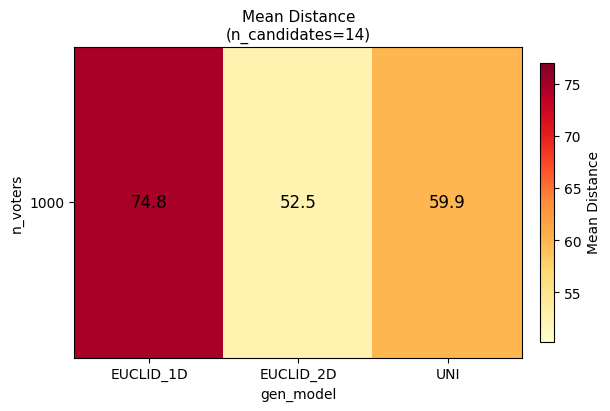

<Axes: title={'center': 'Mean Distance\n(n_candidates=14)'}, xlabel='gen_model', ylabel='n_voters'>

In [7]:
df = results.summary_frame()
print(df.to_string(index=False))

results.filter(gen_model="EUCLID_2D").metric_matrix()

results.plot_metric_heatmap(col_param="gen_model", row_param="n_voters", show=True)

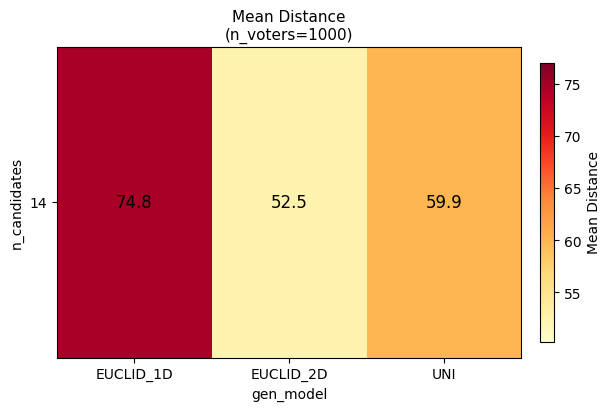

<Axes: title={'center': 'Mean Distance\n(n_voters=1000)'}, xlabel='gen_model', ylabel='n_candidates'>

In [8]:
# Impact of generation model

results.plot_metric_heatmap(col_param="gen_model", row_param="n_candidates", show=True)

## Filtering
As we discussed the model has to be able to "filter" to allow the study of the impact of one parameter

### Filter on number of candidates

gen_model  n_voters  n_candidates  step_count  n_iterations  mean_distance most_distant_rule_a most_distant_rule_b  most_distant_distance
EUCLID_1D      1000            14        1000          1000      74.832165               AP_K5               AP_K6             100.000000
EUCLID_2D      1000            14        1000          1000      52.477675               AP_K9                PLU1              95.166664
      UNI      1000            14        1000          1000      59.930745               AP_K8                PLU1              85.166664


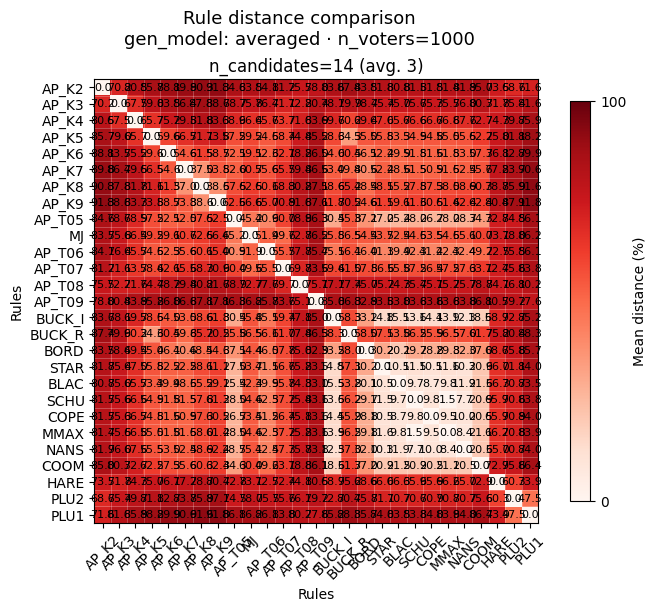

[<Axes: title={'center': 'n_candidates=14 (avg. 3)'}, xlabel='Rules', ylabel='Rules'>]

In [9]:
results_c14 = results.filter(n_candidates=14)
df_c14 = results_c14.summary_frame()
print(df_c14.to_string(index=False))

results.filter(n_candidates=14).plot_comparison_grid(show=True)

## Rule-pair heat map 

In [11]:
results.plot_rule_pair_heatmap("PLU1", "PLU2", show=True)

ValueError: Parameter 'gen_model' has 3 values. Call .filter(gen_model=<value>) first.

## Details of a serie 

In [ ]:
from vote_simulation.models.results.total_result import SeriesKey

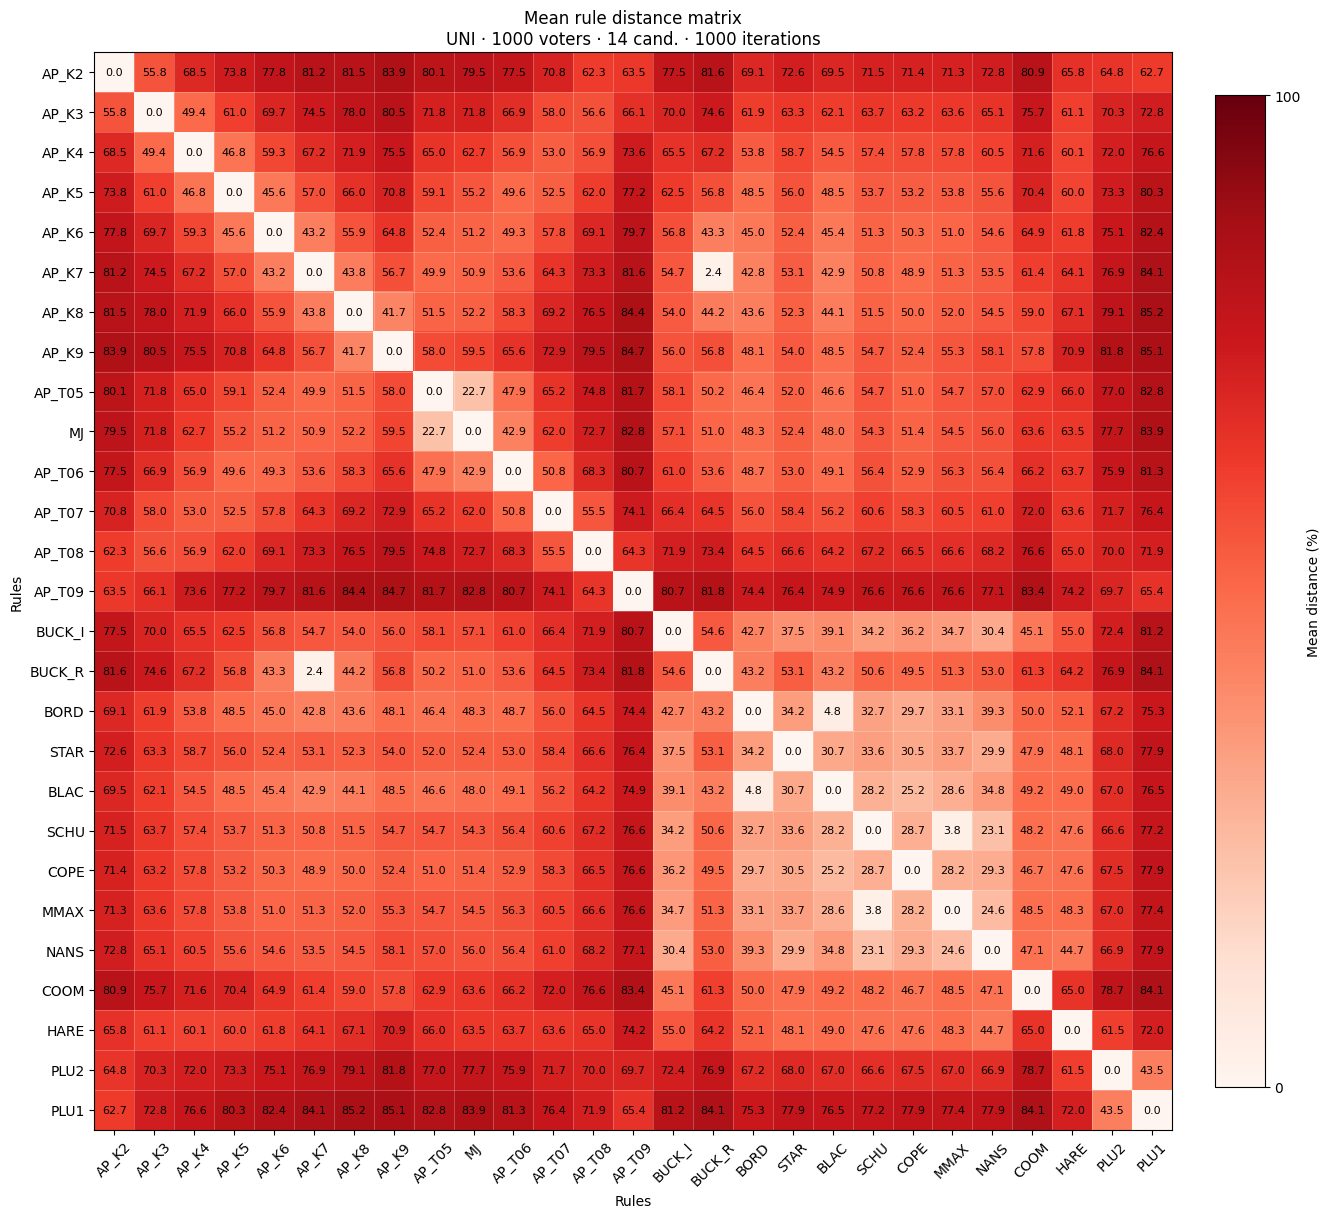

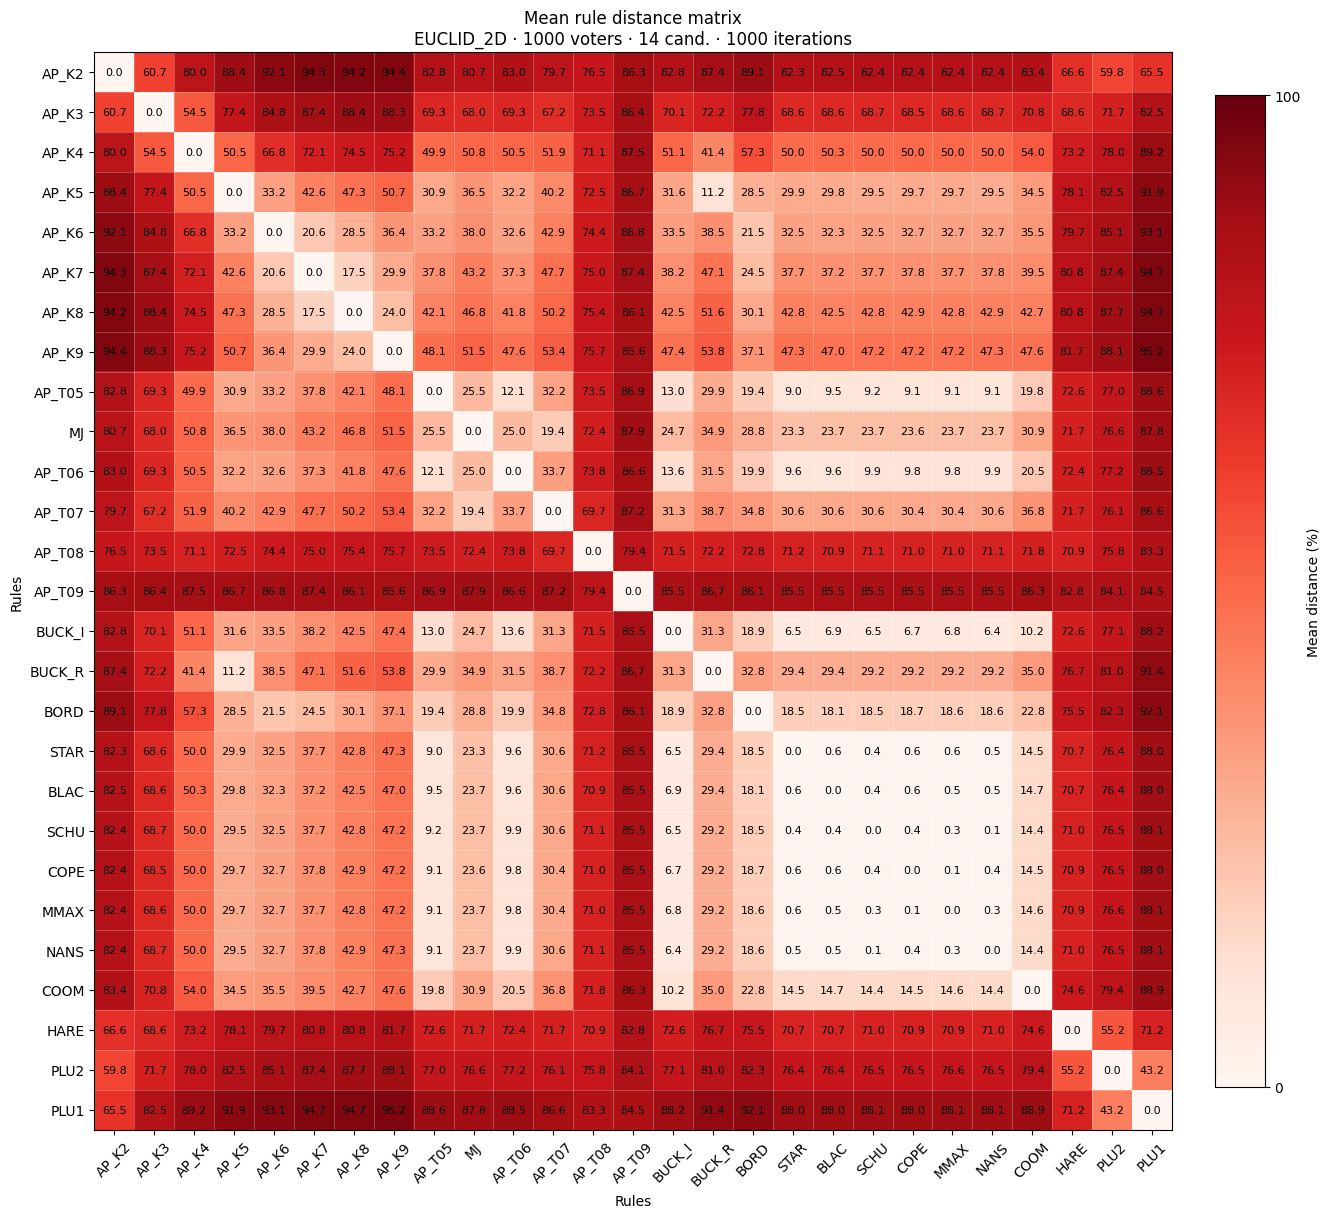

<Axes: title={'center': 'Mean rule distance matrix\nEUCLID_2D · 1000 voters · 14 cand. · 1000 iterations'}, xlabel='Rules', ylabel='Rules'>

In [14]:
# series = results.get_series("UNI",900, 14)
series = results.get_series("UNI", 1000, 14)


series.plot_mean_distance_matrix(show=True)

results.get_series("EUCLID_2D", 1000, 14).plot_mean_distance_matrix(show=True)

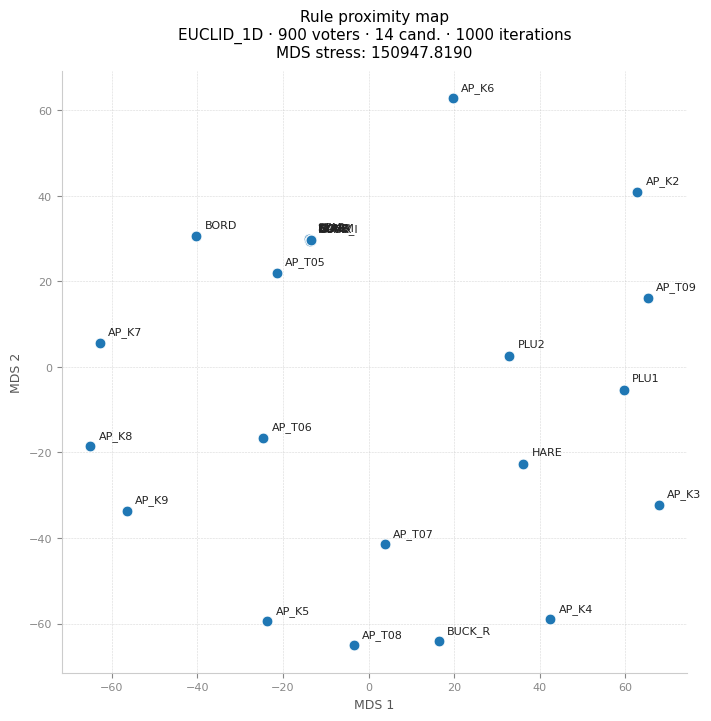

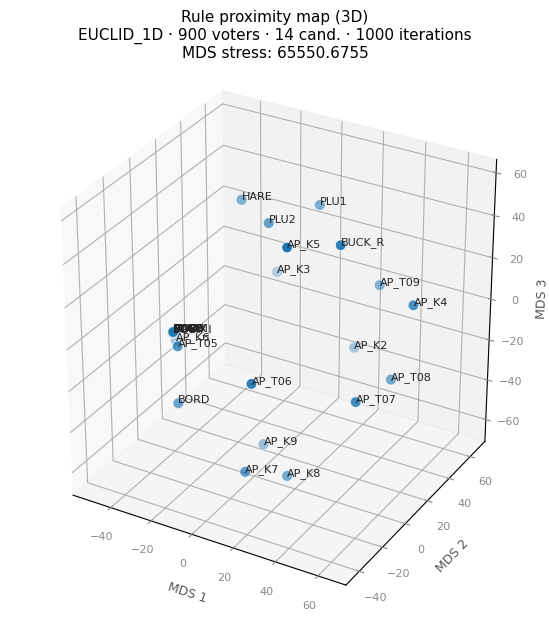

<Axes3D: title={'center': 'Rule proximity map (3D)\nEUCLID_1D · 900 voters · 14 cand. · 1000 iterations\nMDS stress: 65550.6755'}, xlabel='MDS 1', ylabel='MDS 2', zlabel='MDS 3'>

In [13]:
series.plot_rules_2d(show=True)

series.plot_rules_3d(show=True)